# Experiment: SNOMED CT parent-category threshold for symptom-tree terms

**Not a pipeline stage.** This is a standalone experiment to answer one question:

> When we walk up the SNOMED CT `is-a` hierarchy from a symptom-tree term (e.g. `"wisdom teeth extraction"`),
> how far up should we go before adding a parent as extra context for the LLM — i.e. where's the point where
> a parent category (`"procedure in the mouth"`) is still informative, vs. too generic (`"procedure"`) to help?

Approach:
1. Pull every distinct `term` currently appearing in our Stage 3 symptom trees.
2. For each term, look up its SNOMED CT concept on BioPortal and walk its direct-parent chain a few hops up.
3. Embed every term/category label with a local Ollama embedding model.
4. Compute cosine similarity between each term and each ancestor in its chain.
5. Sweep candidate thresholds and inspect what gets kept/dropped, to pick a threshold for general use.

Nothing here writes back into `pipeline.py` or the Stage 3 outputs — it only reads the existing
`symptom_tree_results.json` and writes its own scratch outputs under `data/experiments/snomed_threshold/`.


## 0. Setup

Requires:
- `BIOPORTAL_API_KEY` in `.env` at the repo root (get one free at https://bioportal.bioontology.org/account)
- Ollama running locally with an embedding model pulled: `ollama pull nomic-embed-text`

In [16]:
import sys
import os
import json
import time
from pathlib import Path
from urllib.parse import quote

ROOT = Path.cwd()
if (ROOT / "pipeline.py").exists():
    NB_DIR = ROOT
elif (ROOT / "notebooks" / "pipeline.py").exists():
    NB_DIR = ROOT / "notebooks"
else:
    NB_DIR = ROOT.parent / "notebooks"
sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import requests
from sklearn.metrics.pairwise import cosine_similarity

import pipeline  # side effect: loads .env into os.environ via pipeline._load_dotenv()

BIOPORTAL_API_KEY = os.environ.get("BIOPORTAL_API_KEY")
if not BIOPORTAL_API_KEY:
    raise RuntimeError(
        "BIOPORTAL_API_KEY not set. Add it to the repo-root .env file as:\n"
        "  BIOPORTAL_API_KEY=your_key_here\n"
        "Get a free key at https://bioportal.bioontology.org/account (login required)."
    )

OLLAMA_BASE_URL = pipeline.OLLAMA_BASE_URL
# Switched from nomic-embed-text: it had a specific weak spot on jargon phrases like
# "Pain of truncal structure" (scored as the *lowest*-similarity ancestor in the chain,
# below even the most generic one). mxbai-embed-large is a stronger general-purpose model
# (higher MTEB retrieval score) and fixes that particular outlier, though it does not fully
# solve non-monotonic similarity-vs-depth in every chain (e.g. creatinine, renal mass still
# show some inversion) -- see the section 6 borderline-zone cell for current examples.
EMBED_MODEL = "mxbai-embed-large"

EXPERIMENT_DIR = pipeline.DATA_DIR / "experiments" / "snomed_threshold"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
BIOPORTAL_CACHE_PATH = EXPERIMENT_DIR / "bioportal_cache.json"
# Cache path includes the model name so switching embedding models never silently reuses
# vectors computed by a different model.
EMBEDDING_CACHE_PATH = EXPERIMENT_DIR / f"embedding_cache__{EMBED_MODEL}.json"

print(f"Experiment outputs -> {EXPERIMENT_DIR}")
print(f"Embedding model -> {EMBED_MODEL}")


Experiment outputs -> /Users/hengjialixu/Desktop/ai-agents-for-clinical-coding/data/experiments/snomed_threshold
Embedding model -> mxbai-embed-large


In [17]:
# Sanity check: Ollama is up and the embedding model is pulled
resp = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5)
resp.raise_for_status()
installed = [m["name"] for m in resp.json().get("models", [])]
print("Installed Ollama models:", installed)
if not any(EMBED_MODEL in m for m in installed):
    raise RuntimeError(f"Pull the embedding model first: ollama pull {EMBED_MODEL}")


Installed Ollama models: ['mxbai-embed-large:latest', 'nomic-embed-text:latest', 'qwen2.5:7b']


## 1. Load unique symptom-tree terms from Stage 3

Walks every branch -> symptom -> child in `symptom_tree_results.json` and collects distinct `term` strings.

In [18]:
def collect_terms(tree):
    terms = set()
    for branch in tree.get("branches", []) or []:
        for symptom in branch.get("symptoms", []) or []:
            term = symptom.get("term")
            if term:
                terms.add(term.strip())
            for child in symptom.get("children", []) or []:
                child_term = child.get("term")
                if child_term:
                    terms.add(child_term.strip())
    return terms

results_df, patient_symptom_trees = pipeline.load_symptom_tree_results()

all_terms = set()
for tree in patient_symptom_trees.values():
    all_terms |= collect_terms(tree)

all_terms = sorted(all_terms)
print(f"{len(all_terms)} distinct symptom-tree terms")
all_terms[:15]


97 distinct symptom-tree terms


['Atrial fibrillation/flutter',
 'CHF',
 'DKA',
 'Dilated non-ischemic cardiomyopathy',
 'GERD',
 'GI bleeding',
 'Hepatic encephalopathy',
 'Hypoxic respiratory failure',
 'ICD discharge',
 'ICD shock',
 'Multifocal metastatic HCC',
 'Refractory VT',
 'Renal failure',
 'SVT',
 'Septic shock']

## 2. BioPortal SNOMED CT lookup

For each term: `search` to resolve it to a SNOMED CT concept, then walk `parents` up a few hops.
Everything is cached to disk (`bioportal_cache.json`) so re-running this notebook doesn't re-hit the API.

In [19]:
BIOPORTAL_API = "https://data.bioontology.org"
REQUEST_SLEEP_SECONDS = 0.3  # be polite to the API

def _load_cache(path):
    if path.exists():
        return json.loads(path.read_text())
    return {}

def _save_cache(path, cache):
    path.write_text(json.dumps(cache, indent=2))

bioportal_cache = _load_cache(BIOPORTAL_CACHE_PATH)


def bioportal_search(term):
    """Resolve a free-text term to the best-matching SNOMED CT concept: {id, label} or None."""
    resp = requests.get(
        f"{BIOPORTAL_API}/search",
        params={
            "q": term,
            "ontologies": "SNOMEDCT",
            "require_exact_match": "false",
            "pagesize": 5,
            "apikey": BIOPORTAL_API_KEY,
        },
        timeout=15,
    )
    resp.raise_for_status()
    collection = resp.json().get("collection") or []
    if not collection:
        return None
    top = collection[0]
    return {"id": top["@id"], "label": top.get("prefLabel", "")}


def bioportal_parents(class_iri):
    """Direct is-a parents of a SNOMED CT class: list of {id, label}."""
    encoded = quote(class_iri, safe="")
    resp = requests.get(
        f"{BIOPORTAL_API}/ontologies/SNOMEDCT/classes/{encoded}/parents",
        params={"apikey": BIOPORTAL_API_KEY},
        timeout=15,
    )
    resp.raise_for_status()
    data = resp.json()
    return [
        {"id": p["@id"], "label": p.get("prefLabel", "")}
        for p in data
        if p.get("prefLabel")
    ]


def get_ancestor_chain(term, max_depth=4):
    """
    term -> {"matched_label": str, "matched_id": str, "chain": [{"depth": 1, "id", "label"}, ...]}
    Chain walks the FIRST direct parent at each hop (SNOMED is a DAG; this keeps one representative
    path per term rather than exploding into every branch). depth=1 is the immediate parent.
    """
    match = bioportal_search(term)
    if match is None:
        return {"matched_label": None, "matched_id": None, "chain": []}

    chain = []
    current_id = match["id"]
    seen_ids = {current_id}
    for depth in range(1, max_depth + 1):
        parents = bioportal_parents(current_id)
        time.sleep(REQUEST_SLEEP_SECONDS)
        if not parents:
            break
        parent = parents[0]
        if parent["id"] in seen_ids:
            break
        chain.append({"depth": depth, "id": parent["id"], "label": parent["label"]})
        seen_ids.add(parent["id"])
        current_id = parent["id"]

    return {"matched_label": match["label"], "matched_id": match["id"], "chain": chain}


In [20]:
# One live call first, to sanity-check the response shape before looping over all terms.
_sample_term = all_terms[0]
_sample_match = bioportal_search(_sample_term)
print(f"term={_sample_term!r} -> {_sample_match}")
if _sample_match:
    print(bioportal_parents(_sample_match["id"]))


term='Atrial fibrillation/flutter' -> {'id': 'http://purl.bioontology.org/ontology/SNOMEDCT/5370000', 'label': 'Atrial flutter'}
[{'id': 'http://purl.bioontology.org/ontology/SNOMEDCT/735682000', 'label': 'Macro re-entrant atrial tachycardia'}]


In [21]:
for term in all_terms:
    if term in bioportal_cache:
        continue
    try:
        bioportal_cache[term] = get_ancestor_chain(term)
    except requests.exceptions.HTTPError as exc:
        print(f"  ! {term!r} failed: {exc}")
        bioportal_cache[term] = {"matched_label": None, "matched_id": None, "chain": []}
    time.sleep(REQUEST_SLEEP_SECONDS)
    if len(bioportal_cache) % 25 == 0:
        _save_cache(BIOPORTAL_CACHE_PATH, bioportal_cache)
        print(f"  ...{len(bioportal_cache)}/{len(all_terms)} resolved")

_save_cache(BIOPORTAL_CACHE_PATH, bioportal_cache)

n_unmatched = sum(1 for v in bioportal_cache.values() if not v.get("matched_id"))
print(f"Done. {len(bioportal_cache)} terms cached, {n_unmatched} had no SNOMED CT match.")


Done. 97 terms cached, 0 had no SNOMED CT match.


## 3. Ollama embeddings for every term + ancestor label

Cached to disk (`embedding_cache.json`) since embeddings are reused across every similarity computation below.

In [22]:
embedding_cache_raw = _load_cache(EMBEDDING_CACHE_PATH)
embedding_cache = {k: np.array(v, dtype=np.float32) for k, v in embedding_cache_raw.items()}


def ollama_embed(text):
    if text in embedding_cache:
        return embedding_cache[text]
    resp = requests.post(
        f"{OLLAMA_BASE_URL}/api/embeddings",
        json={"model": EMBED_MODEL, "prompt": text},
        timeout=30,
    )
    resp.raise_for_status()
    vec = np.array(resp.json()["embedding"], dtype=np.float32)
    embedding_cache[text] = vec
    return vec


# Collect every distinct label we need a vector for: terms + their matched concept + every ancestor label.
texts_to_embed = set(all_terms)
for entry in bioportal_cache.values():
    if entry.get("matched_label"):
        texts_to_embed.add(entry["matched_label"])
    for hop in entry.get("chain", []):
        if hop.get("label"):
            texts_to_embed.add(hop["label"])

for i, text in enumerate(sorted(texts_to_embed)):
    ollama_embed(text)
    if (i + 1) % 50 == 0:
        print(f"  ...{i + 1}/{len(texts_to_embed)} embedded")

_save_cache(EMBEDDING_CACHE_PATH, {k: v.tolist() for k, v in embedding_cache.items()})
print(f"Embedded {len(embedding_cache)} distinct strings with {EMBED_MODEL}.")


  ...50/394 embedded
  ...100/394 embedded
  ...150/394 embedded
  ...200/394 embedded
  ...250/394 embedded
  ...300/394 embedded
  ...350/394 embedded
Embedded 394 distinct strings with mxbai-embed-large.


## 4. Cosine similarity per hop

For each term, similarity(term, depth-1 parent), similarity(term, depth-2 parent), etc. — mirroring the
`"wisdom teeth extraction"` -> `"procedure in the mouth"` (~0.5) -> `"procedure"` (~0.2) example.

In [23]:
def cos_sim(a, b):
    return float(cosine_similarity(a.reshape(1, -1), b.reshape(1, -1))[0, 0])


rows = []
for term, entry in bioportal_cache.items():
    if not entry.get("chain"):
        continue
    term_vec = ollama_embed(term)
    prev_label, prev_vec = term, term_vec
    for hop in entry["chain"]:
        label = hop["label"]
        vec = ollama_embed(label)
        rows.append({
            "term": term,
            "matched_snomed_label": entry["matched_label"],
            "depth": hop["depth"],
            "parent_label": label,
            "similarity_to_term": cos_sim(term_vec, vec),
            "similarity_to_prev_hop": cos_sim(prev_vec, vec),
        })
        prev_label, prev_vec = label, vec

similarity_df = pd.DataFrame(rows)
similarity_df.to_csv(EXPERIMENT_DIR / "term_ancestor_similarity.csv", index=False)
print(f"{len(similarity_df)} (term, ancestor) pairs across {similarity_df['term'].nunique()} terms")
similarity_df.head(15)


364 (term, ancestor) pairs across 97 terms


,term,matched_snomed_label,depth,parent_label,similarity_to_term,similarity_to_prev_hop
0,Atrial fibrillation/flutter,Atrial flutter,1,Macro re-entrant atrial tachycardia,0.670018,0.670018
1,Atrial fibrillation/flutter,Atrial flutter,2,Re-entrant atrial tachycardia,0.685843,0.932814
2,Atrial fibrillation/flutter,Atrial flutter,3,Paroxysmal supraventricular tachycardia,0.683164,0.718731
3,Atrial fibrillation/flutter,Atrial flutter,4,Paroxysmal tachycardia,0.698821,0.926207
4,CHF,Congestive heart failure,1,Disorder of cardiac ventricle,0.676765,0.676765
5,CHF,Congestive heart failure,2,Heart disease,0.695560,0.693272
6,CHF,Congestive heart failure,3,Disorder of mediastinum,0.520665,0.606369
7,CHF,Congestive heart failure,4,Disorder of thorax,0.522637,0.867134
8,DKA,Diabetic ketoacidosis,1,Metabolic acidosis due to diabetes mellitus,0.687136,0.687136
9,DKA,Diabetic ketoacidosis,2,Metabolic acidosis,0.635242,0.880890


## 5. Does similarity actually drop off with depth?

If the hypothesis holds, depth-1 parents (most specific) should score higher than depth-3/4 (most generic).

,count,mean,std,min,25%,50%,75%,max
depth,,,,,,,,
1,97.0,0.689159,0.126622,0.375212,0.615524,0.701861,0.767580,0.934133
2,95.0,0.625588,0.104678,0.373574,0.564412,0.624614,0.685481,0.869632
3,92.0,0.599646,0.090494,0.329778,0.538194,0.599528,0.664207,0.829900
4,80.0,0.570305,0.091668,0.298800,0.513612,0.575035,0.626057,0.879193


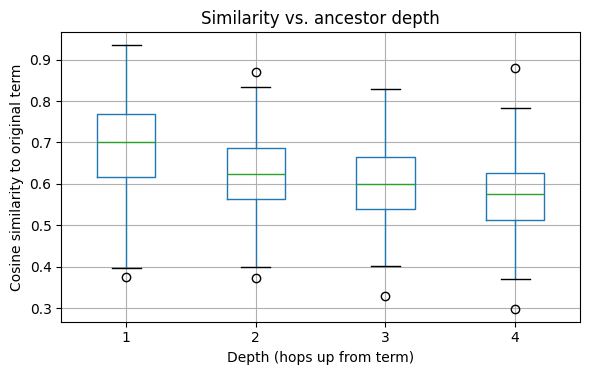

In [24]:
import matplotlib.pyplot as plt

summary = similarity_df.groupby("depth")["similarity_to_term"].describe()
display(summary)

fig, ax = plt.subplots(figsize=(6, 4))
similarity_df.boxplot(column="similarity_to_term", by="depth", ax=ax)
ax.set_xlabel("Depth (hops up from term)")
ax.set_ylabel("Cosine similarity to original term")
ax.set_title("Similarity vs. ancestor depth")
plt.suptitle("")
plt.tight_layout()
plt.show()


## 6. Threshold sweep

For each candidate threshold, how many ancestor hops (on average) would get kept per term, and what does
that look like concretely for a few sample terms?

In [25]:
candidate_thresholds = np.arange(0.20, 0.85, 0.05)

sweep_rows = []
for t in candidate_thresholds:
    kept = similarity_df[similarity_df["similarity_to_term"] >= t]
    kept_per_term = kept.groupby("term").size().reindex(similarity_df["term"].unique(), fill_value=0)
    sweep_rows.append({
        "threshold": round(t, 2),
        "pct_pairs_kept": round(100 * len(kept) / len(similarity_df), 1),
        "avg_ancestors_kept_per_term": round(kept_per_term.mean(), 2),
        # A high absolute-similarity cutoff can look reasonable in the aggregate stats while quietly
        # leaving most terms with NO added context at all — this is the number that catches that.
        "terms_with_zero_kept": int((kept_per_term == 0).sum()),
        "terms_with_zero_kept_pct": round(100 * (kept_per_term == 0).sum() / len(kept_per_term), 1),
    })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df


,threshold,pct_pairs_kept,avg_ancestors_kept_per_term,terms_with_zero_kept,terms_with_zero_kept_pct
0,0.20,100.0,3.75,0,0.0
1,0.25,100.0,3.75,0,0.0
2,0.30,99.7,3.74,0,0.0
3,0.35,99.5,3.73,0,0.0
4,0.40,98.1,3.68,0,0.0
5,0.45,94.0,3.53,2,2.1
6,0.50,87.1,3.27,3,3.1
7,0.55,73.6,2.76,11,11.3
8,0.60,56.3,2.11,18,18.6
9,0.65,38.2,1.43,29,29.9


In [26]:
# Full population, not a random sample: every term's full ancestor chain, sorted by depth-1
# similarity so the "clearly informative" and "clearly too generic" ends of the spectrum are
# easy to scan. A random 10-term sample can look consistent while hiding real variance —
# this is the same data section 6's sweep table summarizes, just readable term-by-term.
terms_by_depth1_sim = (
    similarity_df[similarity_df["depth"] == 1]
    .sort_values("similarity_to_term", ascending=False)["term"]
    .tolist()
)

for term in terms_by_depth1_sim:
    sub = similarity_df[similarity_df["term"] == term].sort_values("depth")
    print(f"\n{term!r}  (matched SNOMED: {sub['matched_snomed_label'].iloc[0]!r})")
    for _, r in sub.iterrows():
        print(f"    depth {r['depth']}: {r['parent_label']!r:45s} sim={r['similarity_to_term']:.3f}")



'heavy vaginal bleeding'  (matched SNOMED: 'Heavy episode of vaginal bleeding')
    depth 1: 'Vaginal bleeding'                            sim=0.934
    depth 2: 'Vagina finding'                              sim=0.625
    depth 3: 'Female genitalia finding'                    sim=0.610
    depth 4: 'Genital finding'                             sim=0.640

'pain in right leg'  (matched SNOMED: 'Pain of right lower leg')
    depth 1: 'Pain in right lower limb'                    sim=0.934
    depth 2: 'Pain in lower limb'                          sim=0.833
    depth 3: 'Finding of sensation of lower limb'          sim=0.694
    depth 4: 'Finding of sensation by site'                sim=0.428

'ciprofloxacin'  (matched SNOMED: 'Ciprofloxacin')
    depth 1: 'Fluoroquinolone'                             sim=0.896
    depth 2: 'Quinolone antibacterial'                     sim=0.669
    depth 3: 'Antibacterial'                               sim=0.674
    depth 4: 'Anti-infective agent'       

In [29]:
# Borderline-zone check: every (term, ancestor) pair within +/- BORDERLINE_WINDOW of a
# candidate threshold. This is where a global cutoff is most likely to misfire — e.g. the
# same parent label ("Pain") can score very differently depending on the child term, so a
# threshold that looks fine in aggregate can still split near-identical relationships into
# kept/dropped inconsistently. Set CANDIDATE_THRESHOLD to whatever you're considering.
CANDIDATE_THRESHOLD = 0.65
BORDERLINE_WINDOW = 0.07

border = similarity_df[
    (similarity_df["similarity_to_term"] >= CANDIDATE_THRESHOLD - BORDERLINE_WINDOW)
    & (similarity_df["similarity_to_term"] <= CANDIDATE_THRESHOLD + BORDERLINE_WINDOW)
].sort_values("similarity_to_term")

print(
    f"{len(border)} pairs within +/-{BORDERLINE_WINDOW} of {CANDIDATE_THRESHOLD} "
    f"({border['term'].nunique()} distinct terms) — inspect these before trusting the cutoff:\n"
)
for _, r in border.iterrows():
    kept = "KEEP" if r["similarity_to_term"] >= CANDIDATE_THRESHOLD else "drop"
    print(f"  [{kept}] {r['term']!r:35s} -> {r['parent_label']!r:45s} sim={r['similarity_to_term']:.3f}")


168 pairs within +/-0.07 of 0.65 (78 distinct terms) — inspect these before trusting the cutoff:

  [drop] 'Hepatic encephalopathy'            -> 'Disorder of head'                            sim=0.581
  [drop] 'intracranial bleeding'             -> 'Clinical finding'                            sim=0.582
  [drop] 'Thrombocytopenia'                  -> 'Clinical finding'                            sim=0.582
  [drop] 'thrombocytopenia'                  -> 'Clinical finding'                            sim=0.582
  [drop] 'respiratory distress'              -> 'Ease of respiration - finding'               sim=0.582
  [drop] 'anorexia'                          -> 'Behavioral syndrome associated with physiological disturbance and physical factors' sim=0.582
  [drop] 'macrocytic anemia'                 -> 'Clinical finding'                            sim=0.583
  [drop] 'mild to moderate AS'               -> 'Grades'                                      sim=0.583
  [drop] 'SVT'                 

## 7. Pick a threshold

Eyeball the sweep table and the per-term breakdowns above. A good threshold is the one where the
parent categories still kept read as genuinely informative (like `"procedure in the mouth"`), and the ones
dropped read as too generic to be useful context (like bare `"procedure"` or `"finding"`).

Set `CHOSEN_THRESHOLD` below once you've decided from the output above.

In [ ]:
CHOSEN_THRESHOLD = None  # fill in after inspecting section 6, e.g. 0.45

if CHOSEN_THRESHOLD is not None:
    kept_df = similarity_df[similarity_df["similarity_to_term"] >= CHOSEN_THRESHOLD]
    out_path = EXPERIMENT_DIR / "chosen_threshold_result.json"
    out_path.write_text(json.dumps({
        "threshold": CHOSEN_THRESHOLD,
        "embed_model": EMBED_MODEL,
        "n_terms": int(similarity_df["term"].nunique()),
        "n_ancestor_pairs_kept": int(len(kept_df)),
        "kept_pairs": kept_df.to_dict(orient="records"),
    }, indent=2))
    print(f"Saved -> {out_path}")
else:
    print("Set CHOSEN_THRESHOLD above, then re-run this cell to save the result.")


## 8. Structural alternative: SNOMED ancestor-count (no embeddings, no LLM)

Cosine similarity turned out to be the wrong signal for "is this ancestor too generic": it's calibrated
per embedding model (`0.55` meant something different for `nomic-embed-text` vs. `mxbai-embed-large`), and
it isn't even reliably monotonic with depth for a *given* model — e.g. `creatinine` → `Substance` scored
*higher* than `creatinine` → `Metabolite`, even though `Substance` is clearly the more generic of the two.

SNOMED CT already encodes genericness structurally, without any embedding at all. If `A is-a B`, then every
ancestor of `B` is also an ancestor of `A` (that's what "is-a" transitivity means), so:

> `ancestor_count(A) > ancestor_count(B)` whenever `A` is-a `B` — a mathematical guarantee, not an empirical trend.

(In practice the gap is often bigger than 1, because SNOMED is a polyhierarchy — a concept can have multiple
direct parents, and `ancestor_count` reflects the union of ancestors from *all* of them, not just the single
parent path we walk. The guarantee is still: strictly decreasing, never by less than 1, along any path we follow.)

This section replaces the cosine-similarity criterion with `ancestor_count(concept)` — how many ancestors a
concept has above it, up to the SNOMED root — fetched directly from BioPortal's `/ancestors` endpoint. The
rule: **keep a hop only if `ancestor_count(hop) >= K`, walking the chain from depth 1 upward and stopping at
the first hop that fails.** Stopping early is provably safe here (unlike with cosine similarity) because
every hop past a failure is guaranteed to also fail.

`K=2` means: don't add a category as context unless it still has at least 2 ancestors of its own between it
and the SNOMED root — i.e. it's not one of SNOMED's ~19 top-level hierarchies (`ancestor_count=0`) or their
immediate children. This cutoff has a fixed, ontology-native meaning that doesn't shift with the embedding
model or the term set, unlike the cosine threshold explored above.

In [ ]:
ANCESTOR_COUNT_CACHE_PATH = EXPERIMENT_DIR / "ancestor_count_cache.json"


def bioportal_ancestor_count(class_iri):
    """Total ancestors of a SNOMED CT class up to the root -- a structural genericness measure."""
    encoded = quote(class_iri, safe="")
    resp = requests.get(
        f"{BIOPORTAL_API}/ontologies/SNOMEDCT/classes/{encoded}/ancestors",
        params={"apikey": BIOPORTAL_API_KEY},
        timeout=15,
    )
    resp.raise_for_status()
    return len(resp.json())


ancestor_count_cache = _load_cache(ANCESTOR_COUNT_CACHE_PATH)

# Every concept we might need a count for: each term's own matched concept, plus every ancestor
# label already resolved in bioportal_cache's chains. Deduped by concept id (not label -- two
# different labels are never the same concept, but the reverse can happen).
concept_ids = set()
for entry in bioportal_cache.values():
    if entry.get("matched_id"):
        concept_ids.add(entry["matched_id"])
    for hop in entry.get("chain", []):
        concept_ids.add(hop["id"])

for i, cid in enumerate(sorted(concept_ids)):
    if cid in ancestor_count_cache:
        continue
    try:
        ancestor_count_cache[cid] = bioportal_ancestor_count(cid)
    except requests.exceptions.HTTPError as exc:
        print(f"  ! {cid} failed: {exc}")
        ancestor_count_cache[cid] = None
    time.sleep(REQUEST_SLEEP_SECONDS)
    if (i + 1) % 50 == 0:
        _save_cache(ANCESTOR_COUNT_CACHE_PATH, ancestor_count_cache)
        print(f"  ...{i + 1}/{len(concept_ids)} resolved")

_save_cache(ANCESTOR_COUNT_CACHE_PATH, ancestor_count_cache)
n_ok = sum(1 for v in ancestor_count_cache.values() if v is not None)
print(f"Ancestor counts resolved for {n_ok}/{len(ancestor_count_cache)} distinct SNOMED concepts.")


### 8a. Apply the K=2 rule

In [ ]:
STRUCTURAL_K = 2  # keep a hop only if it still has >= K ancestors above it (i.e. not near-root/too generic)


def structural_parent_categories(term, k=STRUCTURAL_K):
    """
    Walk `term`'s direct-parent chain (already resolved in bioportal_cache) from depth 1 upward,
    stopping at the first hop whose ancestor_count falls below k. Monotonicity is guaranteed
    (ancestor_count strictly decreases along any is-a chain), so stopping early never skips a
    hop further out that would have passed.
    Returns (kept_hops, first_dropped_hop_or_None).
    """
    entry = bioportal_cache.get(term, {})
    kept = []
    for hop in entry.get("chain", []):
        ac = ancestor_count_cache.get(hop["id"])
        if ac is None:
            continue  # failed lookup -- skip rather than guess
        if ac >= k:
            kept.append({**hop, "ancestor_count": ac})
        else:
            return kept, {**hop, "ancestor_count": ac}
    return kept, None


structural_rows = []
for term in bioportal_cache:
    kept, first_dropped = structural_parent_categories(term)
    structural_rows.append({
        "term": term,
        "matched_snomed_label": bioportal_cache[term].get("matched_label"),
        "n_kept": len(kept),
        "kept_labels": [h["label"] for h in kept],
        "kept_ancestor_counts": [h["ancestor_count"] for h in kept],
        "first_dropped_label": first_dropped["label"] if first_dropped else None,
        "first_dropped_ancestor_count": first_dropped["ancestor_count"] if first_dropped else None,
    })

structural_df = pd.DataFrame(structural_rows)
structural_df.to_csv(EXPERIMENT_DIR / f"structural_k{STRUCTURAL_K}_result.csv", index=False)

print(f"K={STRUCTURAL_K}")
print(f"{len(structural_df)} terms total")
print(f"terms with >=1 category kept: {(structural_df['n_kept'] > 0).sum()} "
      f"({100 * (structural_df['n_kept'] > 0).mean():.1f}%)")
print(f"terms with zero kept: {(structural_df['n_kept'] == 0).sum()} "
      f"({100 * (structural_df['n_kept'] == 0).mean():.1f}%)")
print(f"avg categories kept per term: {structural_df['n_kept'].mean():.2f}")


### 8b. Full kept/dropped listing, for review

Sorted by `n_kept` ascending so the zero- and low-context terms (the ones most worth scrutinizing) are at
the top, rather than buried in a random sample.

In [ ]:
for _, r in structural_df.sort_values(["n_kept", "term"]).iterrows():
    if r["kept_labels"]:
        kept_str = " -> ".join(
            f"{lbl} (anc={ac})" for lbl, ac in zip(r["kept_labels"], r["kept_ancestor_counts"])
        )
    else:
        kept_str = "(none)"
    stop_str = (
        f"  [stopped at: {r['first_dropped_label']!r} anc={r['first_dropped_ancestor_count']}]"
        if r["first_dropped_label"] else "  [reached end of chain, nothing failed]"
    )
    print(f"{r['term']!r:35s} (matched: {r['matched_snomed_label']!r})")
    print(f"    kept: {kept_str}{stop_str}")
